In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
ROOT = "/content/drive/MyDrive/ml in med/lab3/archive (23)/Infection Segmentation Data/Infection Segmentation Data"

In [ ]:
splits = ["Train", "Val", "Test"]
classes = ["COVID-19", "Non-COVID", "Normal"]

for split in splits:
    print(f"\n===== {split} =====")
    for cls in classes:
        img_dir = os.path.join(ROOT, split, cls, "images")
        mask_dir = os.path.join(ROOT, split, cls, "infection masks")

        if os.path.exists(img_dir):
            n_images = len(os.listdir(img_dir))
            n_masks = len(os.listdir(mask_dir))
            print(f"{cls}: Images = {n_images}, Masks = {n_masks}")


===== Train =====
COVID-19: Images = 1864, Masks = 1864
Non-COVID: Images = 932, Masks = 932
Normal: Images = 932, Masks = 932

===== Val =====
COVID-19: Images = 466, Masks = 466
Non-COVID: Images = 233, Masks = 233
Normal: Images = 233, Masks = 233

===== Test =====
COVID-19: Images = 583, Masks = 583
Non-COVID: Images = 292, Masks = 292
Normal: Images = 291, Masks = 291


In [ ]:
for split in ["Train"]:
    print(f"\nChecking matching in {split}")

    for cls in classes:
        img_dir = os.path.join(ROOT, split, cls, "images")
        mask_dir = os.path.join(ROOT, split, cls, "infection masks")

        img_files = set(os.listdir(img_dir))
        mask_files = set(os.listdir(mask_dir))

        missing_masks = img_files - mask_files

        print(f"{cls}: Missing masks = {len(missing_masks)}")



Checking matching in Train
COVID-19: Missing masks = 0
Non-COVID: Missing masks = 0
Normal: Missing masks = 0


In [ ]:
sample_img_path = os.path.join(ROOT, "Train", "COVID-19", "images",
                               os.listdir(os.path.join(ROOT, "Train", "COVID-19", "images"))[0])

sample_mask_path = os.path.join(ROOT, "Train", "COVID-19", "infection masks",
                                os.listdir(os.path.join(ROOT, "Train", "COVID-19", "infection masks"))[0])

img = cv2.imread(sample_img_path)
mask = cv2.imread(sample_mask_path, 0)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask))


Image shape: (256, 256, 3)
Mask shape: (256, 256)
Mask unique values: [  0 255]


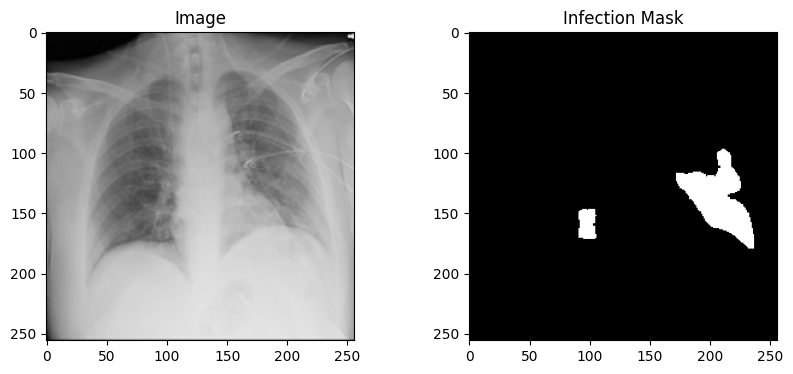

In [ ]:
def show_sample(split="Train", cls="COVID-19"):
    img_dir = os.path.join(ROOT, split, cls, "images")
    mask_dir = os.path.join(ROOT, split, cls, "infection masks")

    file = np.random.choice(os.listdir(img_dir))

    img = cv2.imread(os.path.join(img_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, file), 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Infection Mask")

    plt.show()

show_sample("Train", "COVID-19")


In [ ]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [ ]:
class CovidInfectionDataset(Dataset):
    def __init__(self, root_dir, split="Train"):
        self.samples = []
        self.root_dir = root_dir
        self.split = split

        categories = ["COVID-19", "Non-COVID", "Normal"]

        for category in categories:
            img_dir = os.path.join(root_dir, split, category, "images")
            mask_dir = os.path.join(root_dir, split, category, "infection masks")

            for img_name in os.listdir(img_dir):
                img_path = os.path.join(img_dir, img_name)
                mask_path = os.path.join(mask_dir, img_name)
                self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = cv2.imread(img_path)
        image = cv2.resize(image, (256,256))
        image = image / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (256,256))
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = CovidInfectionDataset(ROOT, split="Train")
val_dataset = CovidInfectionDataset(ROOT, split="Val")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = torch.nn.BCEWithLogitsLoss()

def loss_fn(outputs, masks):
    return dice_loss(outputs, masks) + bce_loss(outputs, masks)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

Epoch 1/10 [Val]: 100%|██████████| 117/117 [10:38<00:00,  5.46s/it]


Epoch 1/10
Train Loss: 1.0036 | Train Dice: 0.6164
Val   Loss: 0.3309 | Val   Dice: 0.4013
--------------------------------------------------


Epoch 2/10 [Val]: 100%|██████████| 117/117 [00:22<00:00,  5.16it/s]


Epoch 2/10
Train Loss: 0.5265 | Train Dice: 0.7465
Val   Loss: 0.1970 | Val   Dice: 0.4175
--------------------------------------------------


Epoch 3/10 [Val]: 100%|██████████| 117/117 [00:19<00:00,  6.09it/s]


...

Epoch 8/10
Train Loss: 0.1967 | Train Dice: 0.8708
Val   Loss: 0.1522 | Val   Dice: 0.4270
--------------------------------------------------


Epoch 9/10 [Val]: 100%|██████████| 117/117 [00:20<00:00,  5.84it/s]


Epoch 9/10
Train Loss: 0.1784 | Train Dice: 0.8796
Val   Loss: 0.1633 | Val   Dice: 0.4227
--------------------------------------------------


Epoch 10/10 [Val]: 100%|██████████| 117/117 [00:21<00:00,  5.57it/s]


Epoch 10/10
Train Loss: 0.1728 | Train Dice: 0.8800
Val   Loss: 0.1602 | Val   Dice: 0.4255
--------------------------------------------------


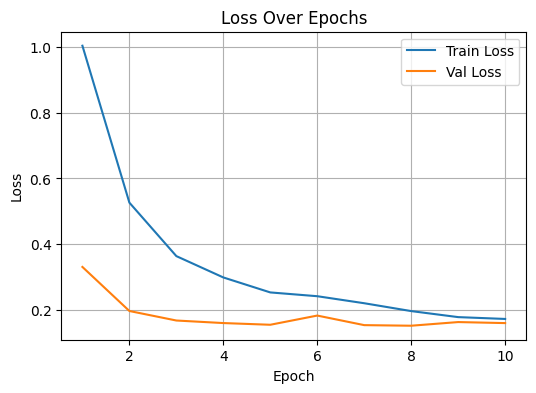

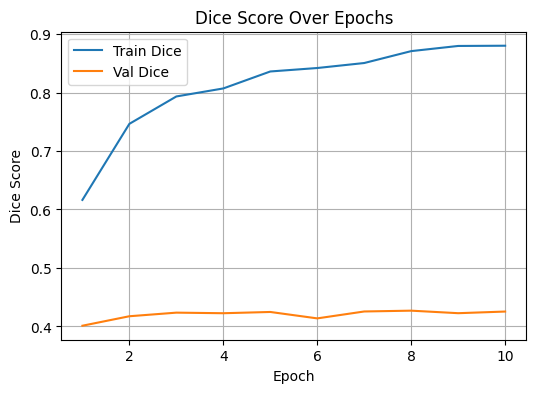

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 10

train_losses, val_losses = [], []
train_dices,  val_dices  = [], []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images = images.to(device)
        masks  = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(outputs, masks).item()

    train_loss_epoch = train_loss / len(train_loader)
    train_dice_epoch = train_dice / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images = images.to(device)
            masks  = masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)

            val_loss += loss.item()
            val_dice += dice_score(outputs, masks).item()

    val_loss_epoch = val_loss / len(val_loader)
    val_dice_epoch = val_dice / len(val_loader)

    # store history
    train_losses.append(train_loss_epoch)
    val_losses.append(val_loss_epoch)
    train_dices.append(train_dice_epoch)
    val_dices.append(val_dice_epoch)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss_epoch:.4f} | Train Dice: {train_dice_epoch:.4f}")
    print(f"Val   Loss: {val_loss_epoch:.4f} | Val   Dice: {val_dice_epoch:.4f}")
    print("-"*50)

# ---- PLOTS ----
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_dices, label="Train Dice")
plt.plot(epochs, val_dices, label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save(model.state_dict(), "unet_covid_infection.pth")

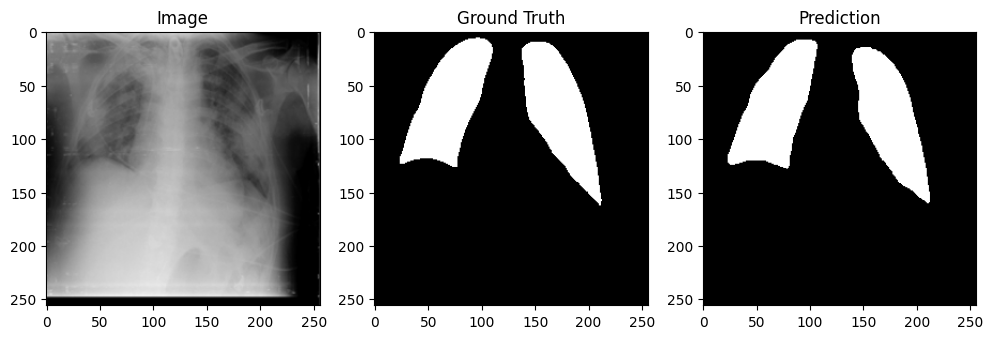

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

img = images[0].cpu().permute(1,2,0).numpy()
mask = masks[0][0].numpy()
pred = preds[0][0].cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")

plt.show()